In [2]:
from google.colab import files
uploaded = files.upload()


Saving img_calculadora.tif to img_calculadora.tif


"""1.1 Carga de la imagen de entrada
a) Cargar la imagen desde el archivo img_calculadora.tif y mostrarla en una figura.


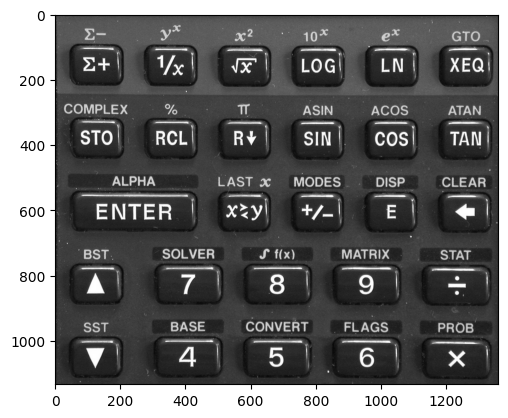

(<Figure size 640x480 with 1 Axes>,
 None)

In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle


img = cv2.imread("img_calculadora.tif", cv2.IMREAD_GRAYSCALE)
plt.figure(),plt.imshow(img, cmap='gray'), plt.show(block=False)

b) Determinar sus dimensiones y el tipo de dato con el cual se representa el valor de cada píxel.




In [6]:
print(img.shape)
img.dtype

(1134, 1360)


dtype('uint8')

c) Determinar el valor mínimo y máximo del nivel de grises de la imagen.

In [7]:
print(img.min(), img.max())

12 255


d) Hallar todos los valores de nivel de grises que tiene la imagen. ¿Cuántos son?

In [10]:
print(np.unique(img))
len(np.unique(img))




[ 12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29
  30  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47
  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65
  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83
  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119
 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155
 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173
 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191
 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209
 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227
 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245
 246 247 248 249 250 251 252 253 254 255]


244

e) ¿Cuál es el valor de nivel de gris con menor repetitividad? ¿Cuál es el valor de nivel de gris con mayor repetitividad? Considere que, en ambos casos, pueden ser más de uno. En tal caso, mostrarlos todos. """

In [11]:
valores, conteo = np.unique(img, return_counts=True)
print(valores[np.where(conteo == conteo.min())])
print(valores[np.where(conteo == conteo.max())])

[12 13 14]
[71]


In [13]:
valores, conteos = np.unique(img, return_counts=True)

for v, c in zip(valores, conteos):
    print(f"Valor: {v} | Conteo: {c}")

Valor: 12 | Conteo: 1
Valor: 13 | Conteo: 1
Valor: 14 | Conteo: 1
Valor: 15 | Conteo: 14
Valor: 16 | Conteo: 20
Valor: 17 | Conteo: 35
Valor: 18 | Conteo: 64
Valor: 19 | Conteo: 157
Valor: 20 | Conteo: 304
Valor: 21 | Conteo: 507
Valor: 22 | Conteo: 806
Valor: 23 | Conteo: 1197
Valor: 24 | Conteo: 1661
Valor: 25 | Conteo: 2285
Valor: 26 | Conteo: 3091
Valor: 27 | Conteo: 3894
Valor: 28 | Conteo: 5005
Valor: 29 | Conteo: 5723
Valor: 30 | Conteo: 6571
Valor: 31 | Conteo: 7141
Valor: 32 | Conteo: 7728
Valor: 33 | Conteo: 7695
Valor: 34 | Conteo: 7974
Valor: 35 | Conteo: 7948
Valor: 36 | Conteo: 7927
Valor: 37 | Conteo: 8032
Valor: 38 | Conteo: 8384
Valor: 39 | Conteo: 9002
Valor: 40 | Conteo: 10114
Valor: 41 | Conteo: 11800
Valor: 42 | Conteo: 14190
Valor: 43 | Conteo: 16795
Valor: 44 | Conteo: 19970
Valor: 45 | Conteo: 23592
Valor: 46 | Conteo: 26846
Valor: 47 | Conteo: 29260
Valor: 48 | Conteo: 30376
Valor: 49 | Conteo: 30451
Valor: 50 | Conteo: 30169
Valor: 51 | Conteo: 29014
Valor: 52

""".2 Segmentación con ROI
f)
Recortar las teclas con las etiquetas: ‘SIN’, ‘COS’ y ‘TAN’. Los tres recortes deben ser
del mismo tamaño. Mostrar los recortes en una nueva figura utilizando subplots (uno
para cada región recortada), con los títulos acordes.

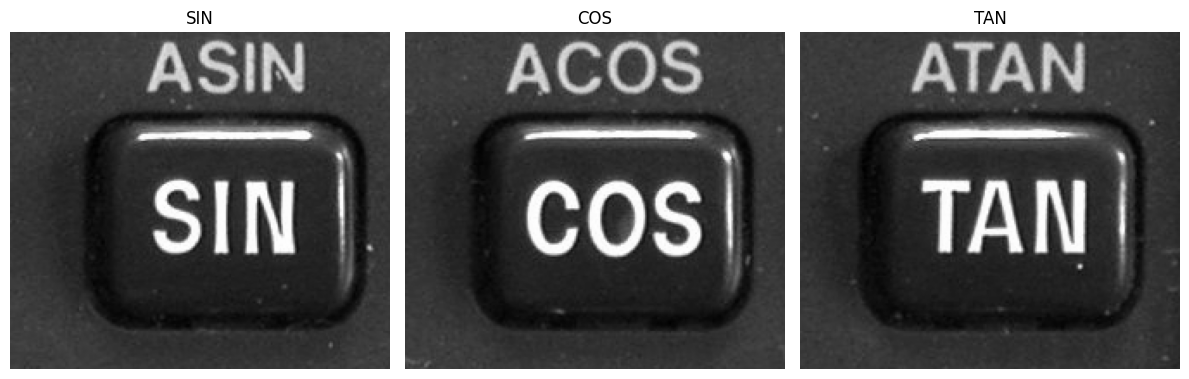

In [26]:
sin_roi = img[275:470, 680:900].copy()
cos_roi = img[275:470, 910:1130].copy()
tan_roi = img[275:470, 1140:1360].copy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(sin_roi, cmap='gray')
plt.title("SIN")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cos_roi, cmap='gray')
plt.title("COS")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(tan_roi, cmap='gray')
plt.title("TAN")
plt.axis("off")

plt.tight_layout()
plt.show()

g) Pegar cada recorte en una copia de la imagen original, de manera tal que las teclas
de la calculadora queden ordenadas con la secuencia: | ‘TAN’ |  | ‘COS’ |  | ‘SIN’ |.

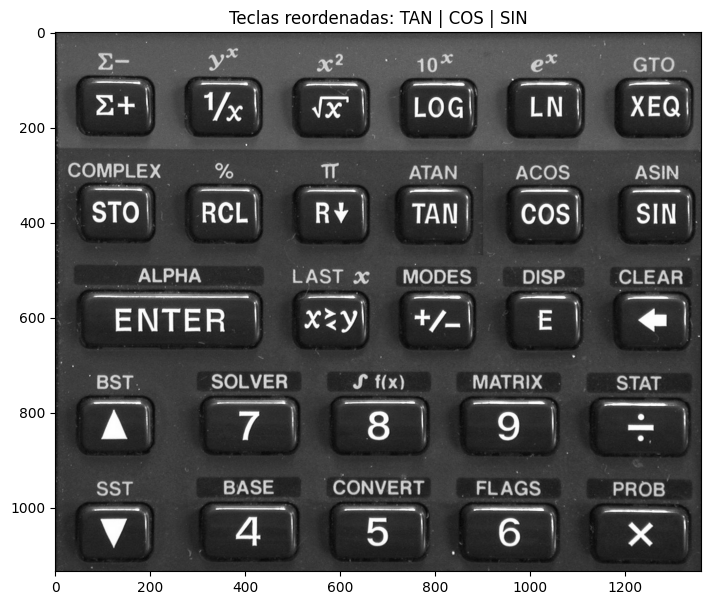

In [27]:
img_g = img.copy()

img_g[275:470, 680:900] = tan_roi
img_g[275:470, 910:1130] = cos_roi
img_g[275:470, 1140:1360] = sin_roi

plt.figure(figsize=(10,7))
plt.imshow(img_g, cmap='gray')
plt.title("Teclas reordenadas: TAN | COS | SIN")
plt.show()



h) A partir de la imagen resultante, recortar la tecla con etiqueta ‘ENTER’ y pegarla en el
lugar de la tecla con etiqueta ‘COS’ (tenga presente que ambas teclas tienen
diferentes tamaños).


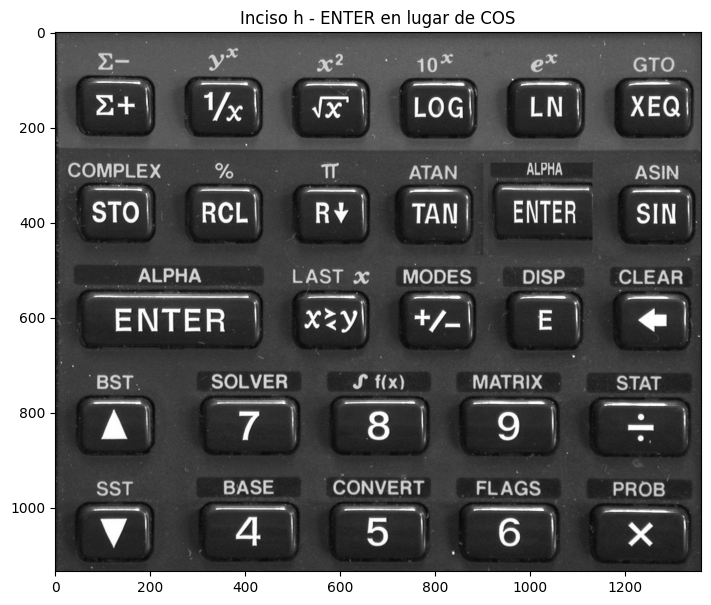

In [32]:
enter_roi = img_g[500:700, 30:420].copy()

y1_cos, y2_cos = 275, 470
x1_cos, x2_cos = 910, 1130

alto_cos = y2_cos - y1_cos
ancho_cos = x2_cos - x1_cos

enter_resize = cv2.resize(enter_roi, (ancho_cos, alto_cos), interpolation=cv2.INTER_AREA)

img_h = img_g.copy()
img_h[y1_cos:y2_cos, x1_cos:x2_cos] = enter_resize

plt.figure(figsize=(10,7))
plt.imshow(img_h, cmap='gray')
plt.title("Inciso h - ENTER en lugar de COS")
plt.show()

i)
Aplicar modificaciones en la imagen resultante de manera tal que las teclas ‘4’, ‘5’, ‘6’,
‘7’, ‘8’ y ‘9’ posean sus etiquetas numéricas pintadas de gris. Por ejemplo, cada
etiqueta numérica con valor = 170."""

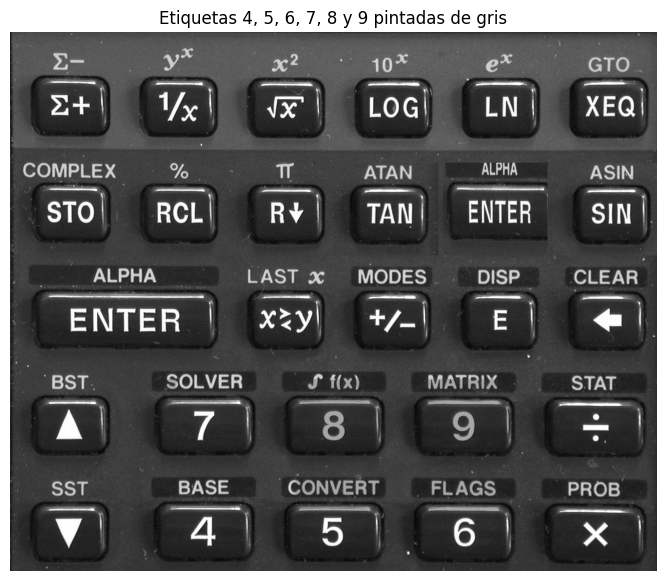

In [33]:
def pintar_numero_gris(imagen, y1, y2, x1, x2, umbral=170, gris=170):
    roi = imagen[y1:y2, x1:x2].copy()
    mascara = roi > umbral

    roi[mascara] = gris
    imagen[y1:y2, x1:x2] = roi

img_i = img_h.copy()

# 7
pintar_numero_gris(img_i, 730, 860, 250, 350, umbral=170, gris=170)

# 8
pintar_numero_gris(img_i, 730, 860, 600, 800, umbral=170, gris=170)

# 9
pintar_numero_gris(img_i, 730, 860, 850, 1060, umbral=170, gris=170)

# 4
pintar_numero_gris(img_i, 900, 1020, 250, 350, umbral=170, gris=170)

# 5
pintar_numero_gris(img_i, 900, 1020, 600, 800, umbral=170, gris=170)

# 6
pintar_numero_gris(img_i, 900, 1020, 850, 1060, umbral=170, gris=170)

plt.figure(figsize=(10,7))
plt.imshow(img_i, cmap='gray')
plt.title("Etiquetas 4, 5, 6, 7, 8 y 9 pintadas de gris")
plt.axis("off")
plt.show()